In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
os.environ["HUGGINGFACEHUB_API_KEY"]=os.getenv("HUGGINGFACEHUB_API_KEY")
os.environ["HF_TOKEN"]=os.getenv("HF_TOKEN")

In [2]:
#build index
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings

embd=HuggingFaceEmbeddings()

urls=[
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
    "https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm",
]

#load
docs=[WebBaseLoader(url).load() for url in urls]
doc_list=[item for sublist in docs for item in sublist]

text_splitter=RecursiveCharacterTextSplitter(chunk_size=1000,chunk_overlap=100)
doc_splits=text_splitter.split_documents(doc_list)

vector_store=FAISS.from_documents(
    documents=doc_splits,
    embedding=HuggingFaceEmbeddings()
)

retriever=vector_store.as_retriever()

e:\Agents\agent\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\Moham\AppData\Local\Temp\ipykernel_20508\2321527465.py:3: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import WebBaseLoader
USER_AGENT environment variable not set, consider setting it to identify your requests.


In [3]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_groq import ChatGroq
from langchain_core.tools import create_retriever_tool
from langchain_community.tools.tavily_search import TavilySearchResults
from pydantic import BaseModel, Field
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_classic import hub
from typing import Annotated, Sequence, Literal
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages
from langgraph.graph import END, StateGraph, START
from langgraph.prebuilt import ToolNode, tools_condition
from IPython.display import Image, display

#data model
class GradeDocuments(BaseModel):
    """Binary score for relevance check."""
    binary_score: str = Field(description="Relevance score 'yes' or 'no'")

# Create retriever tool
retriever_tool = create_retriever_tool(
    retriever,
    "retrieve_documents",
    "Search and retrieve information about agents, prompting, and adversarial attacks on LLMs"
)

# Web search tool
web_search_tool = TavilySearchResults(k=3)

tools = [retriever_tool, web_search_tool]

C:\Users\Moham\AppData\Local\Temp\ipykernel_20508\2226853126.py:29: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  web_search_tool = TavilySearchResults(k=3)


In [4]:
# Define Agent State
class AgentState(TypedDict):
    """The state of the agent."""
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [14]:
# Agent Node
def agent(state):
    """
    Invoke the agent model to generate a response based on the current state.
    Given the question, it will decide to retrieve tools, web search, or simply end.
    
    Args:
        state (messages): the current state
    
    Returns:
        dict: the updated state with the agent response appended to messages
    """
    print("---CALL AGENT---")
    messages = state["messages"]
    model = ChatGroq(model="groq:qwen/qwen3.6-32b")
    model = model.bind_tools(tools)
    response = model.invoke(messages)
    return {"messages": [response]}

In [15]:
# Grade Documents Node
def grade_documents(state) -> Literal["generate", "web_search"]:
    """
    Determines whether the retrieved documents are relevant to the question.
    If not relevant, can perform web search.
    
    Args:
        state (messages): the current state
    
    Returns:
        str: a decision for whether to generate or web search
    """
    print("---CHECK RELEVANCE---")
    
    # LLM with structured output
    model = ChatGroq(model="groq:qwen/qwen3.6-32b")
    llm_with_tool = model.with_structured_output(GradeDocuments)
    
    # Prompt for grading
    prompt = ChatPromptTemplate.from_template(
        """You are a grader assessing relevance of a retrieved document to a user question.
        
        Here is the retrieved document: {context}
        
        Here is the user question: {question}
        
        If the document contains keywords or semantic meaning related to the user question, grade it as relevant.
        Give a binary score 'yes' or 'no' to indicate whether the document is relevant to the question."""
    )
    
    # Chain
    chain = prompt | llm_with_tool
    
    messages = state["messages"]
    last_message = messages[-1]
    
    question = messages[0].content
    docs = last_message.content
    
    scored_result = chain.invoke({"question": question, "context": docs})
    score = scored_result.binary_score
    
    if score == "yes":
        print("---DECISION: DOCS RELEVANT---")
        return "generate"
    else:
        print("---DECISION: DOCS NOT RELEVANT--")
        return "web_search"

In [16]:
# Web Search Node
def web_search(state):
    """
    Perform web search when retrieved documents are not relevant.
    
    Args:
        state (messages): The current state
    
    Returns:
        dict: The updated state with web search results
    """
    print("---WEB SEARCH---")
    messages = state["messages"]
    question = messages[0].content
    
    # Web search
    results = web_search_tool.invoke({"query": question})
    
    # Format results as a string
    web_results = "\n".join([result["content"] for result in results])
    
    return {"messages": [HumanMessage(content=web_results)]}

In [ ]:
# Retrieve Node
def retriever_node(state):
    """
    Fetch documents with the original question, then keep them in state.
    """
    print("---RETRIEVE---")
    messages = state["messages"]
    question = messages[0].content

    docs = retriever.invoke(question)
    context = "\n\n".join(doc.page_content for doc in docs)
    return {"messages": [HumanMessage(content=context)]}


# Transform Query Node
def transform_query(state):
    """
    Rephrase the question and re-run the vector search with the improved query.
    """
    print("---TRANSFORM QUERY---")
    messages = state["messages"]
    question = messages[0].content

    rewrite_prompt = [
        HumanMessage(
            content=f"""Look at the input and try to reason about the underlying semantic intent and meaning.

Here is the initial question:
--------
{question}

--------

    return {"messages": [HumanMessage(content=context)]}

Formulate an improved question:"""    context = "\n\n".join(doc.page_content for doc in docs)

        )    docs = retriever.invoke(improved_query)

    ]

    improved_query = rewritten.content

    model = ChatGroq(model="groq:qwen/qwen3.6-32b")    rewritten = model.invoke(rewrite_prompt)

In [18]:
# Generate Node
def generate(state):
    """
    Generate answer based on retrieved or web search documents.
    
    Args:
        state (messages): The current state
    
    Returns:
        dict: The updated message with generated response
    """
    print("---GENERATE---")
    messages = state["messages"]
    question = messages[0].content
    last_message = messages[-1]
    
    docs = last_message.content
    
    # Prompt
    prompt = hub.pull("rlm/rag-prompt")
    
    # LLM
    llm = ChatGroq(model="groq:qwen/qwen3.6-32b")
    
    # Chain
    rag_chain = prompt | llm | StrOutputParser()
    
    # Run
    response = rag_chain.invoke({"context": docs, "question": question})
    return {"messages": [HumanMessage(content=response)]}

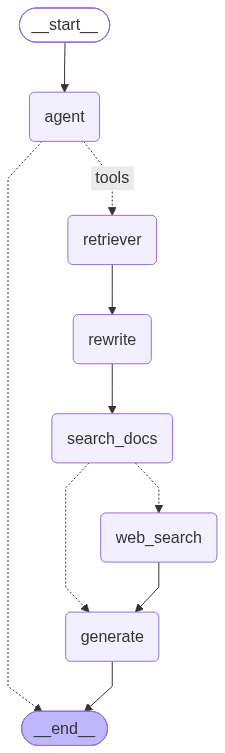

In [ ]:
# Build the LangGraph Workflow
workflow = StateGraph(AgentState)

# Add nodes
workflow.add_node("retriever", retriever_node)
workflow.add_node("transform_query", transform_query)
workflow.add_node("web_search", web_search)
workflow.add_node("generate", generate)

# Add edges
workflow.add_edge(START, "retriever")
workflow.add_edge("retriever", "transform_query")

# Grade the transformed search results: generate if relevant, otherwise do web search
workflow.add_conditional_edges(
    "transform_query",
    grade_documents,
    {
        "generate": "generate",
        "web_search": "web_search",
    },
)

workflow.add_edge("generate", END)
workflow.add_edge("web_search", "generate")

# Compile the graph
graph = workflow.compile()


display(Image(graph.get_graph().draw_mermaid_png()))# Display the graph

In [21]:
# Test the corrective RAG workflow
result = graph.invoke({"messages": [HumanMessage(content="What is an agent in the context of LLMs?")]})
print("\nFinal Response:")
print(result["messages"][-1].content)

---CALL AGENT---


NotFoundError: Error code: 404 - {'error': {'message': 'The model `groq:qwen/qwen3.6-32b` does not exist or you do not have access to it.', 'type': 'invalid_request_error', 'code': 'model_not_found'}}